# SIGMA vs scGate - Tem cytotoxic T cell extraction
## Dominguez et al. cross-tissue human immune atlas (Science, 2022)

**Comparison of SIGMA and scGate (marker-based hierarchical cell gating with
positive AND negative signatures) for the targeted extraction of effector memory
cytotoxic T cells.**

scGate (an R/Seurat method built on UCell) is run directly from this Python
notebook via **rpy2** - the raw counts matrix is transferred to R as a sparse
matrix and the whole scGate pipeline (Seurat preprocessing, UCell scoring, kNN
smoothing, adaptive gating) executes in-process, with the per-cell purity label
pulled back into Python. There is no separate R notebook and no intermediate CSV:
this is a single, self-contained comparison notebook.

### Why scGate is the most relevant comparator
Unlike UCell (positive scoring only) and CellID (per-cell hypergeometric
enrichment, positive signatures only), scGate is - together with SIGMA - the only
method here that natively models **exclusion markers**: a gating model combines a
positive signature (genes that must be high) and a negative signature (genes that
must be low). This mirrors SIGMA's target / exclusion logic directly.

Also unlike CellID/UCell, **scGate does not return a continuous score to threshold
at an arbitrary percentile**. It returns a hard purity label `is.pure` in
{`Pure`, `Impure`} from its own internal gating (UCell scores + kNN smoothing +
adaptive thresholds). So **scGate+ = cells labelled `Pure`** - no percentile cutoff
is chosen by hand.

### Model (single level, aligned with the UCell/CellID notebooks)
- positive signature = [Target] genes (config/StudyCaseDominguez.conf)
- negative signature = [LowIn] genes (declared via `gating_model(..., negative = TRUE)`)

No separate T/CD8 candidate gate is used, so the comparison is strictly aligned
with the UCell and CellID notebooks.

### Datasets
- Full dataset: Dominguez Conde et al., Science 2022 (doi: 10.1126/science.abl5197)
- SIGMA output: `dominguez_merge-bic.h5ad` (BIC component selection, score threshold >= 0.95)

### scGate reference
- Andreatta et al., Bioinformatics 2022 (doi: 10.1093/bioinformatics/btac141)

### Validation approach
Selections are evaluated using three biologically unambiguous marker panels,
independent of clustering or annotation quality:
- T cell identity markers (CD3E, TRAC, CD8A, CD8B)
- NK cell contamination markers (NCAM1, KLRD1, FCGR3A, GNLY)
- Non-cytotoxic T cell markers (CD4, FOXP3, TCF7, SELL)

There is no universally accepted ground truth for single-cell annotation, so this
evaluates biological coherence (marker expression) rather than agreement with a
"true" label.

### Prerequisites (documented only - nothing in this notebook installs anything)
- Python: `rpy2` (`pip install rpy2`)
- R, reachable from this Python environment, with `Seurat`, `Matrix` and `scGate`
  installed:
  ```r
  install.packages(c("Seurat", "Matrix", "scGate"))  # scGate pulls UCell as a dependency
  ```


In [1]:
import os
os.environ["R_HOME"] = "/home/lemgui01/.miniconda3/envs/sigma_compare/lib/R"

import numpy as np
import scipy.sparse as sp
import scanpy as sc
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

r_base   = importr("base")
r_matrix = importr("Matrix")
r_seurat = importr("Seurat")
r_scgate = importr("scGate")

---
## Configuration

In [2]:
# --- Paths ---
PATH_FULL  = "/mnt/projects_tn03/AD_EB_singlecell/archive/Dominguez_science_science-abl5197.h5ad"
PATH_SIGMA = "/mnt/projects_tn03/AD_EB_singlecell/articleSIGMA-results/results_dominguez/merge.h5ad"

# --- SIGMA threshold ---
SIGMA_THRESHOLD = 0.95

# --- scGate gene sets (config/StudyCaseDominguez.conf: [Target] / [LowIn]) ---
TARGET_GENES = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]

EXCLUSION_GENES = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3",
                   "TRDC", "TRGC1", "TRGC2"]

# The scGate gating model is built in R (section 4) as a single level with the
# Target genes as positive markers and the LowIn genes as negative markers.
# scGate returns a hard `is.pure` label (Pure/Impure); there is no percentile cutoff.

# --- Validation marker panels ---
T_CELL_MARKERS = ["CD3E", "TRAC", "CD8A", "CD8B"]
NK_MARKERS     = ["NCAM1", "KLRD1", "FCGR3A", "GNLY"]
NON_CYTOTOXIC  = ["CD4", "FOXP3", "TCF7", "SELL"]

# --- Plot colors ---
BLUE  = "#1f77b4"   # SIGMA+
GREEN = "#2ca02c"   # scGate+
rng = np.random.default_rng(42)

---
## 1. Data loading

In [4]:
adata_full  = sc.read_h5ad(PATH_FULL)
adata_sigma = sc.read_h5ad(PATH_SIGMA)

print(f"adata_full  : {adata_full.shape[0]:,} cells x {adata_full.shape[1]:,} genes")
print(f"adata_sigma : {adata_sigma.shape[0]:,} cells x {adata_sigma.shape[1]:,} genes")

adata_full  : 329,762 cells x 36,601 genes
adata_sigma : 41,214 cells x 36,601 genes


---
## 2. SIGMA+ labeling

In [5]:
adata_sigma_thresh = adata_sigma[adata_sigma.obs["score"] >= SIGMA_THRESHOLD].copy()

adata_sigma_thresh.obs_names = adata_sigma_thresh.obs_names.str.replace(
    r"-Dominguez_.*?_data$", "", regex=True
)

adata_full.obs["sigma_positive"] = adata_full.obs_names.isin(set(adata_sigma_thresh.obs_names))

mask_sigma = adata_full.obs["sigma_positive"]
print(f"SIGMA+ : {mask_sigma.sum():,}")

SIGMA+ : 2,698


---
## 3. Transfer counts to R (rpy2)

The raw counts matrix (`adata_full.layers["counts"]` if present, else `.X`) is
converted to an R `dgCMatrix` and pushed into R's global environment through
rpy2, keyed on the same barcodes as `adata_full.obs_names` so results can be
matched back to Python by position.

In [6]:
def scipy_to_r_dgCMatrix(X, genes, cells):
    """Convert a genes x cells scipy CSC matrix to an R Matrix::dgCMatrix with dimnames."""
    X = X.tocsc()
    with localconverter(ro.default_converter + numpy2ri.converter):
        r_i = ro.IntVector(X.indices)
        r_p = ro.IntVector(X.indptr)
        r_x = ro.FloatVector(X.data)
    r_dimnames = ro.r["list"](ro.StrVector(genes), ro.StrVector(cells))
    return r_matrix.sparseMatrix(
        i=r_i, p=r_p, x=r_x,
        dims=ro.IntVector(X.shape),
        index1=False,
        dimnames=r_dimnames,
        repr="C",
    )

counts = adata_full.layers["counts"] if "counts" in adata_full.layers else adata_full.X
counts_gxc = sp.csc_matrix(counts).T  # genes x cells, as Seurat expects

r_counts = scipy_to_r_dgCMatrix(
    counts_gxc,
    genes=adata_full.var_names.tolist(),
    cells=adata_full.obs_names.tolist(),
)
ro.globalenv["counts_mat"]      = r_counts
ro.globalenv["target_genes"]    = ro.StrVector(TARGET_GENES)
ro.globalenv["exclusion_genes"] = ro.StrVector(EXCLUSION_GENES)

print(f"Transferred to R: {counts_gxc.shape[0]:,} genes x {counts_gxc.shape[1]:,} cells")

Transferred to R: 36,601 genes x 329,762 cells


---
## 4. scGate: Seurat preprocessing and marker-based gating

A single-level gating model is built with two `gating_model()` calls: the Target
genes as **positive** markers, then the LowIn genes appended as **negative**
markers (`negative = TRUE`). This is the documented, unambiguous way to declare an
exclusion signature in scGate - the `GENE-` suffix is *not* parsed by
`gating_model()` and would be treated as a (non-existent) positive gene. scGate
scores each cell with UCell, smooths the scores over the kNN graph, and applies
adaptive thresholds to return a hard `is.pure` label per cell.

In [7]:
ro.r("""
seurat_obj <- Seurat::CreateSeuratObject(counts = counts_mat)
seurat_obj <- Seurat::NormalizeData(seurat_obj)

# Single level: Target genes = positive markers, LowIn genes = negative markers.
model_tem <- scGate::gating_model(name = "Tem", signature = target_genes)
model_tem <- scGate::gating_model(model = model_tem, name = "Tem_exclusion",
                                  signature = exclusion_genes, negative = TRUE)

seurat_obj <- scGate::scGate(seurat_obj, model = model_tem, ncores = 1)

# scGate stores the purity label in `is.pure` (single model). Fall back to the
# level-1 column if the version used a different name.
if (!is.null(seurat_obj$is.pure)) {
    is_pure <- as.character(seurat_obj$is.pure)
} else {
    is_pure <- as.character(seurat_obj$is.pure.level1)
}
""")

with localconverter(ro.default_converter + numpy2ri.converter):
    is_pure = np.array(ro.globalenv["is_pure"], dtype=object)

# `is_pure` follows the column order of counts_mat, i.e. adata_full.obs_names.
adata_full.obs["scgate_positive"] = (is_pure == "Pure")
mask_scgate = adata_full.obs["scgate_positive"]

print(f"SIGMA+  : {mask_sigma.sum():,}")
print(f"scGate+ : {mask_scgate.sum():,}")
print(f"Overlap : {(mask_sigma & mask_scgate).sum():,}")

R callback write-console: Normalizing layer: counts
  
R callback write-console: Performing log-normalization
  
R callback write-console: 0%   10   20   30   40   50   60   70   80   90   100%
  
R callback write-console: [----|----|----|----|----|----|----|----|----|----|
  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R callback write-console: *  
R 

SIGMA+  : 2,698
scGate+ : 135,169
Overlap : 2,324


---
## 5. Overlap figure (Venn diagram: SIGMA+ vs scGate+)

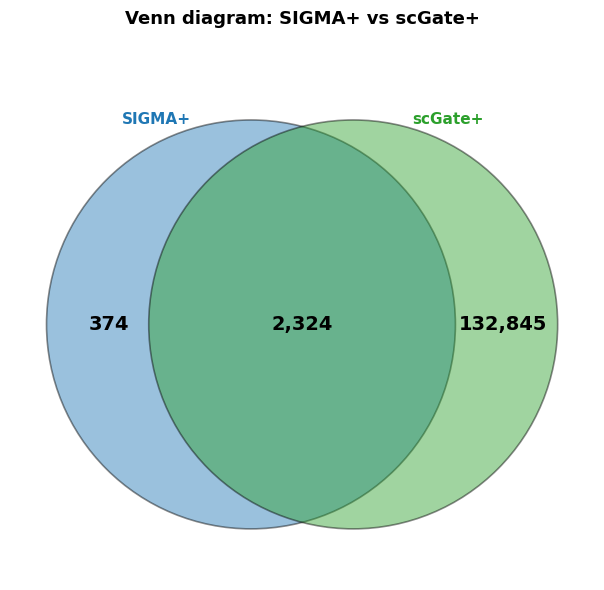

In [8]:
n_sigma  = int(mask_sigma.sum())
n_scgate = int(mask_scgate.sum())
n_both   = int((mask_sigma & mask_scgate).sum())

n_sigma_only  = n_sigma - n_both
n_scgate_only = n_scgate - n_both

fig, ax = plt.subplots(figsize=(7, 6))

c1 = plt.Circle((0.43, 0.5), 0.28, color=BLUE, alpha=0.45, ec="black", lw=1.2)
c2 = plt.Circle((0.57, 0.5), 0.28, color=GREEN, alpha=0.45, ec="black", lw=1.2)
ax.add_patch(c1)
ax.add_patch(c2)

ax.text(0.235, 0.50, f"{n_sigma_only:,}", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(0.50, 0.50, f"{n_both:,}", ha="center", va="center", fontsize=14, fontweight="bold")
ax.text(0.775, 0.50, f"{n_scgate_only:,}", ha="center", va="center", fontsize=14, fontweight="bold")

ax.text(0.30, 0.78, "SIGMA+", ha="center", va="center", fontsize=11, fontweight="bold", color=BLUE)
ax.text(0.70, 0.78, "scGate+", ha="center", va="center", fontsize=11, fontweight="bold", color=GREEN)

ax.set_title("Venn diagram: SIGMA+ vs scGate+", fontsize=13, fontweight="bold")
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.15, 0.9)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
fig.savefig("figures/SUP4-A.pdf", bbox_inches="tight", dpi=500)
plt.show()

---
## 6. log1p-CPM normalization

In [9]:
adata_norm = adata_full.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e6)
sc.pp.log1p(adata_norm)

---
## 7. Utility functions

In [10]:
def get_expression(adata, mask, gene):
    """Retrieve log1p-CPM expression values for a given gene and mask."""
    if gene not in adata.var_names:
        return np.array([])
    idx = adata.var_names.get_loc(gene)
    expr = adata.X[mask, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    return np.array(expr).flatten()

def mean_panel(adata, mask, genes):
    """Compute the mean expression of a list of genes for a given mask."""
    genes_ok = [g for g in genes if g in adata.var_names]
    if not genes_ok:
        return np.zeros(int(mask.sum()))
    idx = [adata.var_names.get_loc(g) for g in genes_ok]
    expr = adata.X[mask][:, idx]
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    return np.mean(expr, axis=1)

def format_pvalue(pval):
    return f"{pval:.3e}"

def boxplot_panel(ax, v1, v2, title, rng, n_sample=1000):
    """Boxplot comparing two sets of expression values (v1 = SIGMA, v2 = scGate)."""
    for i, (vals, color) in enumerate([(v1, BLUE), (v2, GREEN)], start=1):
        bp = ax.boxplot(
            [v1, v2][i - 1:i],
            positions=[i], patch_artist=True, widths=0.5,
            notch=False, showfliers=False,
            medianprops=dict(color="black", linewidth=2), zorder=3
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        for w in bp["whiskers"]: w.set(linewidth=1.0, linestyle="--")
        for c in bp["caps"]:     c.set(linewidth=1.0)

        s   = rng.choice(len(vals), size=min(n_sample, len(vals)), replace=False)
        jit = rng.uniform(-0.12, 0.12, size=len(s))
        ax.scatter(i + jit, vals[s], color=color, alpha=0.3, s=6, zorder=2, linewidths=0)

    stat, pval = mannwhitneyu(v1, v2, alternative="two-sided")
    ax.set_title(title + f"\np = {format_pvalue(pval)}", fontsize=11, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"SIGMA+\n(n={len(v1):,})", f"scGate+\n(n={len(v2):,})"], fontsize=9)
    ax.set_ylabel("log1p-CPM", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return pval

def plot_gene_panel(genes, suptitle, figname, rng, n_cols=4, n_sample=1000, fig_format="pdf"):
    """Plot expression levels for a list of genes, SIGMA+ vs scGate+."""
    genes_ok = [g for g in genes if g in adata_norm.var_names]
    n_rows   = int(np.ceil(len(genes_ok) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = np.atleast_1d(axes).flatten()
    for idx, gene in enumerate(genes_ok):
        boxplot_panel(axes[idx],
                      get_expression(adata_norm, mask_sigma.values, gene),
                      get_expression(adata_norm, mask_scgate.values, gene),
                      gene, rng, n_sample)
    for idx in range(len(genes_ok), len(axes)):
        axes[idx].axis("off")
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{figname}.{fig_format}", bbox_inches="tight", dpi=500)
    plt.show()

---
## 8. Figure C - T cell identity markers

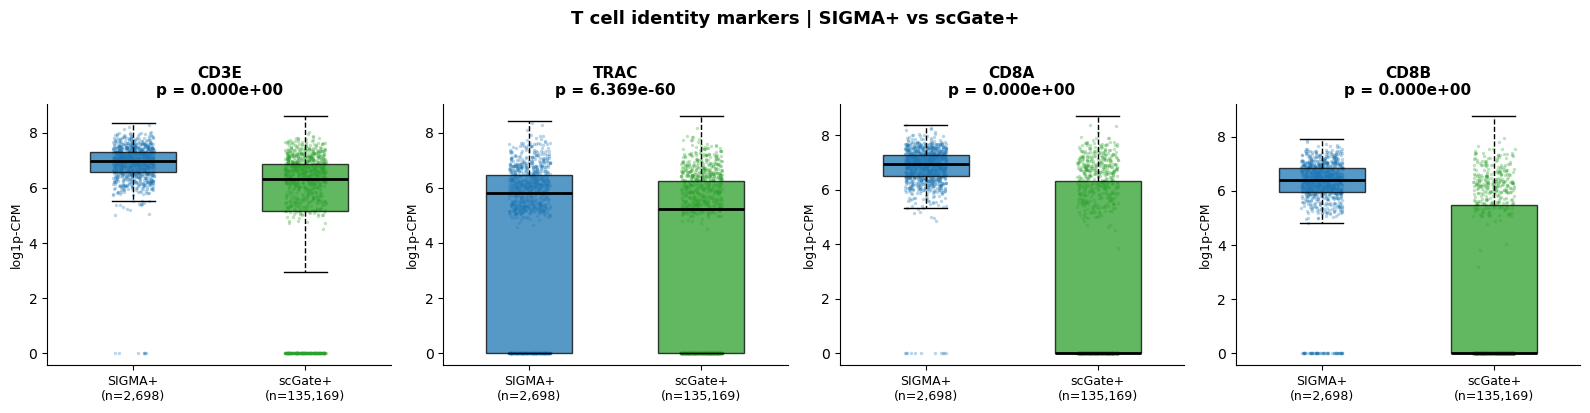

In [11]:
plot_gene_panel(
    T_CELL_MARKERS,
    "T cell identity markers | SIGMA+ vs scGate+",
    "figures/SUP4-C",
    rng
)

---
## 9. Figure D - NK cell contamination markers

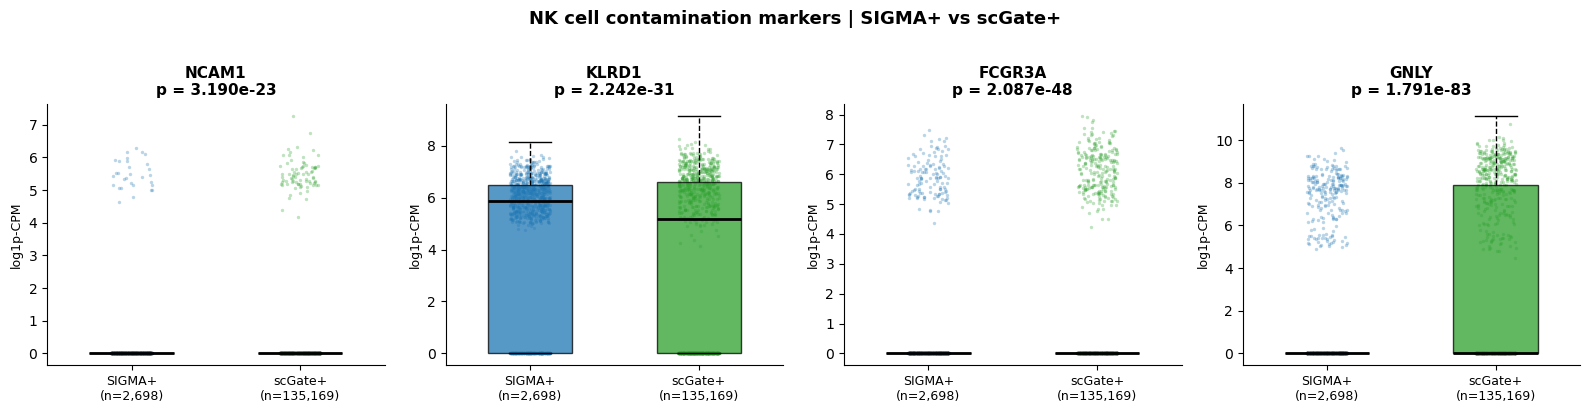

In [12]:
plot_gene_panel(
    NK_MARKERS,
    "NK cell contamination markers | SIGMA+ vs scGate+",
    "figures/SUP4-D",
    rng
)

---
## 10. Figure E - Non-cytotoxic T cell markers

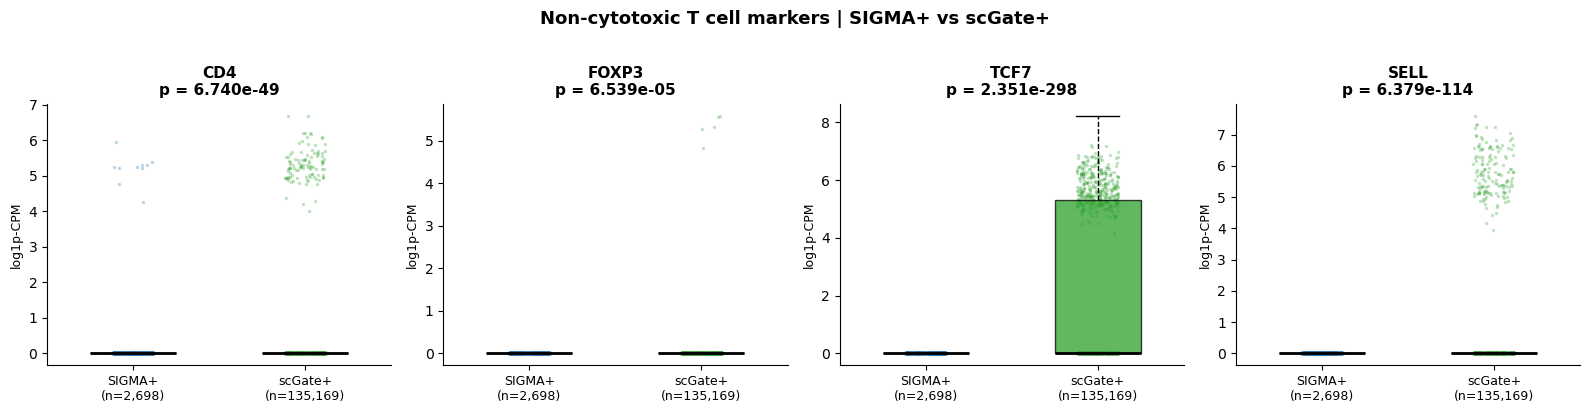

In [13]:
plot_gene_panel(
    NON_CYTOTOXIC,
    "Non-cytotoxic T cell markers | SIGMA+ vs scGate+",
    "figures/SUP4-E",
    rng
)

---
## 11. Figure B - Summary panel scores

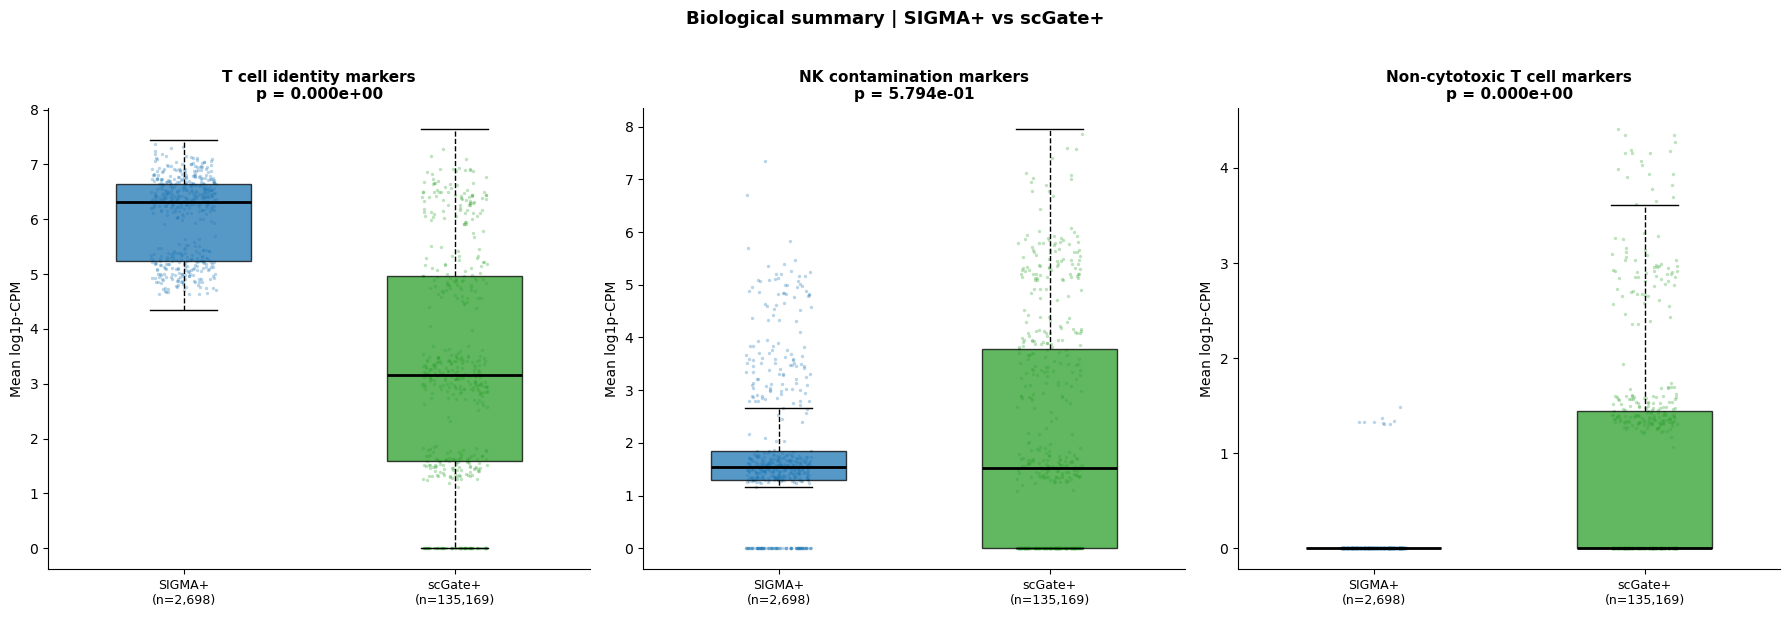

,Panel,SIGMA+ median,scGate+ median,p-value
0,T cell identity markers,6.312,3.152,0.000e+00
1,NK contamination markers,1.535,1.521,5.794e-01
2,Non-cytotoxic T cell markers,0.000,0.000,0.000e+00


In [14]:
panels = [
    (T_CELL_MARKERS, "T cell identity markers"),
    (NK_MARKERS, "NK contamination markers"),
    (NON_CYTOTOXIC,  "Non-cytotoxic T cell markers"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rows = []

for ax, (genes, title) in zip(axes, panels):
    s = mean_panel(adata_norm, mask_sigma.values, genes)
    c = mean_panel(adata_norm, mask_scgate.values, genes)
    pval = boxplot_panel(ax, s, c, title, rng, n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=10)
    rows.append({"Panel": title,
                 "SIGMA+ median": round(float(np.median(s)), 3),
                 "scGate+ median": round(float(np.median(c)), 3),
                 "p-value": format_pvalue(pval)})

fig.suptitle("Biological summary | SIGMA+ vs scGate+", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("figures/SUP4-B.pdf", bbox_inches="tight", dpi=500)
plt.show()

summary_df = pd.DataFrame(rows)
summary_df

---
## 12. Final composite figure

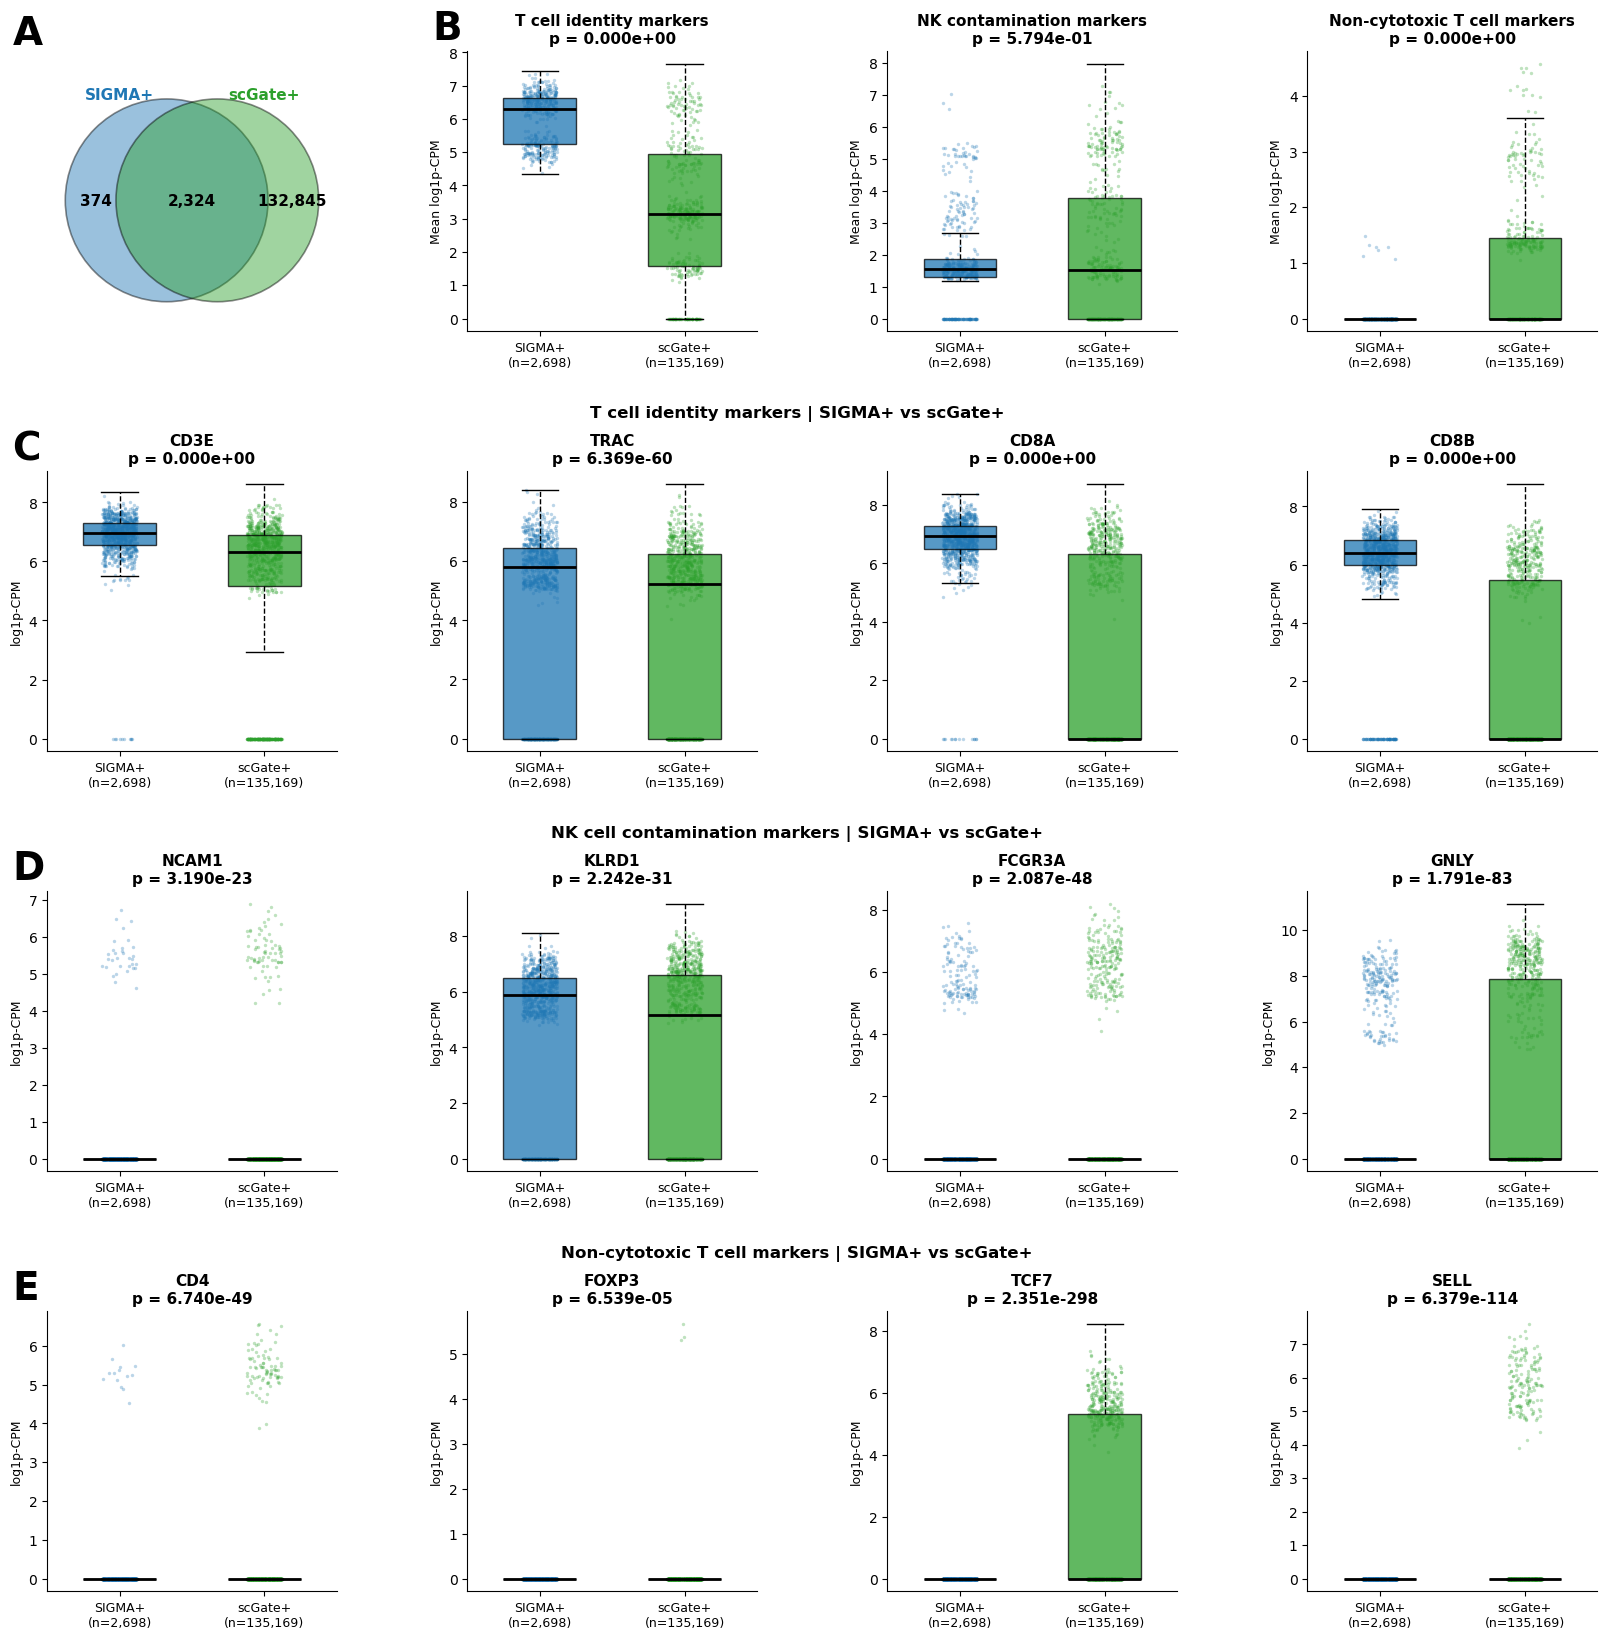

In [15]:
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.45)

ax_venn = fig.add_subplot(gs[0, 0])
axB = [fig.add_subplot(gs[0, i]) for i in range(1, 4)]
axC = [fig.add_subplot(gs[1, i]) for i in range(4)]
axD = [fig.add_subplot(gs[2, i]) for i in range(4)]
axE = [fig.add_subplot(gs[3, i]) for i in range(4)]

# A
c1 = plt.Circle((0.43, 0.5), 0.28, color=BLUE, alpha=0.45, ec="black", lw=1.2)
c2 = plt.Circle((0.57, 0.5), 0.28, color=GREEN, alpha=0.45, ec="black", lw=1.2)
ax_venn.add_patch(c1)
ax_venn.add_patch(c2)
ax_venn.text(0.235, 0.50, f"{n_sigma_only:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.50, 0.50, f"{n_both:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.775, 0.50, f"{n_scgate_only:,}", ha="center", va="center", fontsize=11, fontweight="bold")
ax_venn.text(0.30, 0.78, "SIGMA+", ha="center", fontsize=11, fontweight="bold", color=BLUE)
ax_venn.text(0.70, 0.78, "scGate+", ha="center", fontsize=11, fontweight="bold", color=GREEN)
ax_venn.set_xlim(0.1, 0.9); ax_venn.set_ylim(0.15, 0.9)
ax_venn.set_aspect("equal"); ax_venn.axis("off")
ax_venn.text(-0.12, 1.15, "A", transform=ax_venn.transAxes, fontsize=28, fontweight="bold", va="top")

# B
panels_B = [
    (T_CELL_MARKERS, "T cell identity markers"),
    (NK_MARKERS, "NK contamination markers"),
    (NON_CYTOTOXIC,  "Non-cytotoxic T cell markers"),
]
for ax, (genes, title) in zip(axB, panels_B):
    s = mean_panel(adata_norm, mask_sigma.values, genes)
    c = mean_panel(adata_norm, mask_scgate.values, genes)
    boxplot_panel(ax, s, c, title, rng, n_sample=500)
    ax.set_ylabel("Mean log1p-CPM", fontsize=9)
axB[0].text(-0.12, 1.15, "B", transform=axB[0].transAxes, fontsize=28, fontweight="bold", va="top")

# C, D, E
for axrow, genes_list, letter, title in [
    (axC, T_CELL_MARKERS, "C", "T cell identity markers | SIGMA+ vs scGate+"),
    (axD, NK_MARKERS, "D", "NK cell contamination markers | SIGMA+ vs scGate+"),
    (axE, NON_CYTOTOXIC,  "E", "Non-cytotoxic T cell markers | SIGMA+ vs scGate+"),
]:
    genes_ok = [g for g in genes_list if g in adata_norm.var_names]
    for ax, gene in zip(axrow, genes_ok):
        boxplot_panel(ax,
                      get_expression(adata_norm, mask_sigma.values, gene),
                      get_expression(adata_norm, mask_scgate.values, gene),
                      gene, rng)
    for ax in axrow[len(genes_ok):]:
        ax.axis("off")
    axrow[0].text(-0.12, 1.15, letter, transform=axrow[0].transAxes,
                  fontsize=28, fontweight="bold", va="top")
    top = axrow[0].get_position().y1
    fig.text(0.5, top + 0.025, title, ha="center", va="bottom", fontsize=12, fontweight="bold")

fig.savefig("figures/SUP4-full.pdf", bbox_inches="tight", dpi=500)
plt.show()